The dataset used in this study is the Breast Cancer Wisconsin Diagnostic Dataset, obtained from the Kaggle. This dataset is widely used for developing and evaluating machine learning models for cancer classification.otal samples: 569
Number of features: 30
Target classes:
Malignant (cancerous).
Benign (non-cancerous) The features describe characteristics of the cell nuclei, which are critical for distinguishing between benign and malignant tumors.

In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [84]:

df = pd.read_csv('cancer_classification.csv')

In [85]:
df.shape

(569, 31)

In [86]:
df.head()
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


<Axes: xlabel='benign_0__mal_1', ylabel='count'>

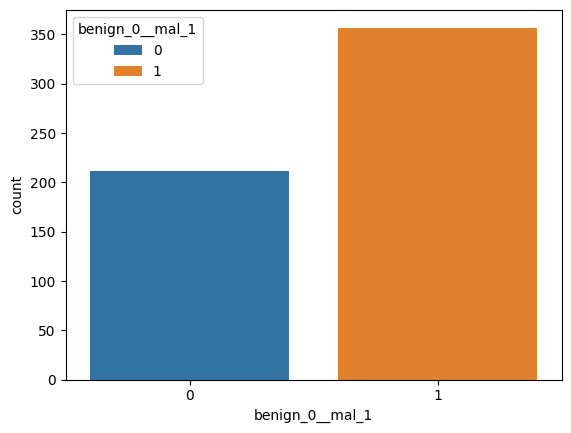

In [87]:
sns.countplot(x ='benign_0__mal_1',data =df,hue='benign_0__mal_1' )

<Axes: >

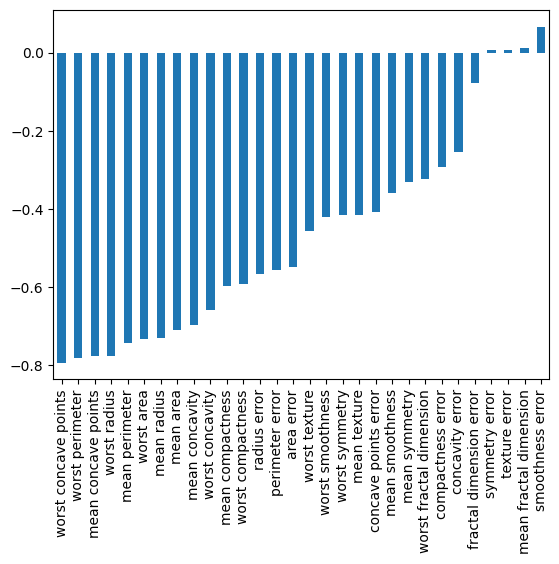

In [88]:
df.corr()['benign_0__mal_1'][:-1].sort_values().plot(kind='bar')

<Axes: >

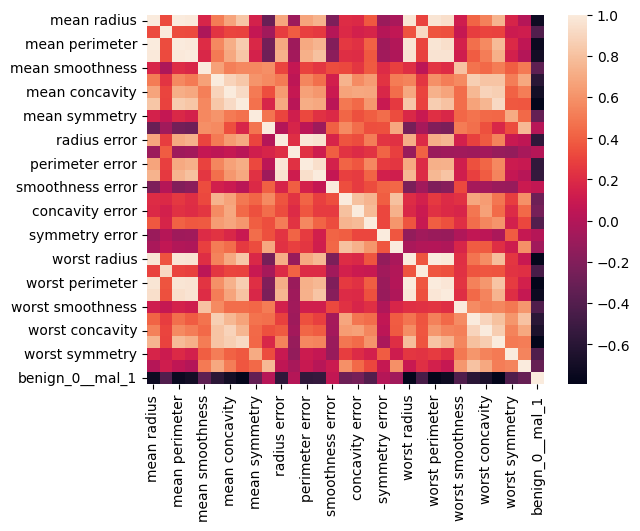

In [89]:
sns.heatmap(df.corr())

In [90]:
X= df.drop('benign_0__mal_1',axis =1).values
y = df['benign_0__mal_1'].values

In [91]:
from sklearn.model_selection import train_test_split

In [92]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.25 , random_state= 101)

In [93]:
from sklearn.preprocessing import MinMaxScaler

In [94]:
scaler = MinMaxScaler()

In [95]:
X_train = scaler.fit_transform(X_train)

In [96]:
X_test = scaler.transform(X_test)

In [97]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

In [98]:
X_train.shape

(426, 30)

In [99]:
model = Sequential()
model.add(Dense(30,activation ='relu'))

model.add(Dense(15,activation ='relu'))

#Binary Classification outputting zero and 1
model.add(Dense(1,activation ='sigmoid'))
model.compile(loss= 'binary_crossentropy', optimizer ='adam')

In [100]:
model.fit(x= X_train,y= y_train,epochs = 600 ,validation_data = (X_test,y_test))

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.6780 - val_loss: 0.6450
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6317 - val_loss: 0.6037
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5892 - val_loss: 0.5608
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5458 - val_loss: 0.5139
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4980 - val_loss: 0.4656
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4503 - val_loss: 0.4180
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3991 - val_loss: 0.3636
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3524 - val_loss: 0.3142
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3064 - val_loss: 0.2726
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2749 - val_loss: 0.2425
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2465 - val_loss: 0.2184
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss

In [101]:
losses = pd.DataFrame(model.history.history)

<Axes: >

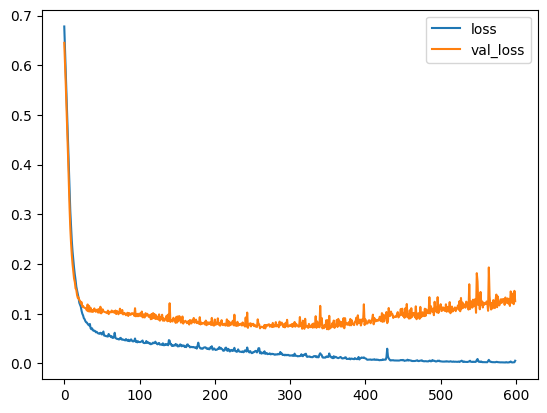

In [102]:
losses.plot()

The plot shows that the training loss decreases steadily throughout training, while the validation loss drops at first but then gradually increases after around 50–100 epochs. This indicates that the model is learning effectively in the early stages, but later continues to fit the training data more closely without improving on unseen data. The widening gap between training and validation loss suggests that the model is overfitting, as it performs much better on the training data than on the validation data. It does not appear to be underfitting, since both losses are low and the model clearly captures patterns in the data, especially early in training.

In [120]:
from tensorflow.keras.callbacks import EarlyStopping

In [121]:
model = Sequential()
model.add(Dense(30,activation ='relu'))

model.add(Dense(15,activation ='relu'))

#Binary Classification outputting zero and 1
model.add(Dense(1,activation ='sigmoid'))
model.compile(loss= 'binary_crossentropy', optimizer ='adam')

In [122]:
early_stop= EarlyStopping(monitor= 'val_loss',mode ='min',verbose=1,patience=25)

In [123]:
model.fit(x= X_train,y= y_train,epochs = 600 ,validation_data = (X_test,y_test),callbacks= [early_stop])

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.7252 - val_loss: 0.6718
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6590 - val_loss: 0.6294
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.6135 - val_loss: 0.5860
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5676 - val_loss: 0.5370
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5214 - val_loss: 0.4834
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4704 - val_loss: 0.4372
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4173 - val_loss: 0.3803
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3688 - val_loss: 0.3345
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3262 - val_loss: 0.2932
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2921 - val_loss: 0.2611
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2600 - val_loss: 0.2360
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - lo

In [124]:
model_loss =pd.DataFrame(model.history.history)

<Axes: >

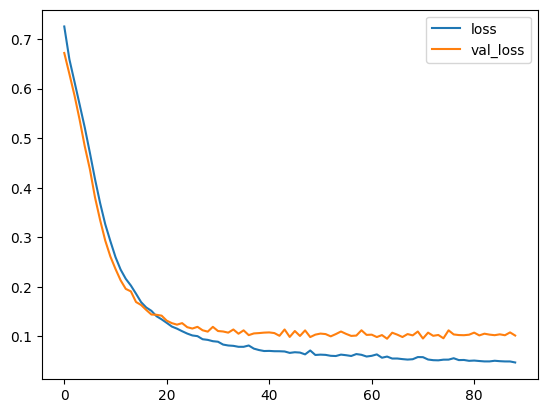

In [125]:
model_loss.plot()


This plot shows a clear improvement over the previous one after adding early stopping. Earlier, the training loss kept decreasing while the validation loss began to rise, indicating overfitting as the model trained for too long. In this case, both training and validation loss decrease together and stay close, with the validation loss stabilizing instead of increasing. This suggests that training was stopped at the right time, preventing overfitting and resulting in better generalization, where the model performs consistently well on both training and unseen data.

In [134]:

from tensorflow.keras.layers import Dropout
model = Sequential()
model.add(Dense(30,activation ='relu'))
model.add(Dropout(0.5))
model.add(Dense(15,activation ='relu'))
model.add(Dropout(0.5))

#Binary Classification outputting zero and 1
model.add(Dense(1,activation ='sigmoid'))
model.compile(loss= 'binary_crossentropy', optimizer ='adam')

In [135]:
early_stop= EarlyStopping(monitor= 'val_loss',mode ='min',verbose=1,patience=25)

In [136]:
model.fit(x= X_train,y= y_train,epochs = 600 ,validation_data = (X_test,y_test),callbacks= [early_stop])

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.7015 - val_loss: 0.6763
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6889 - val_loss: 0.6646
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6660 - val_loss: 0.6479
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6461 - val_loss: 0.6254
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6317 - val_loss: 0.5994
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6221 - val_loss: 0.5749
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6066 - val_loss: 0.5605
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5694 - val_loss: 0.5294
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5337 - val_loss: 0.4968
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5483 - val_loss: 0.4727
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5190 - val_loss: 0.4470
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

In [137]:
model_loss= pd.DataFrame(model.history.history)

<Axes: >

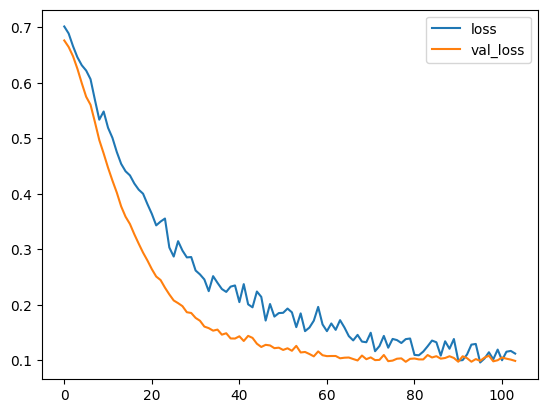

In [138]:
model_loss.plot()

In [139]:
predictions= model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [140]:
y_pred_classes = (predictions > 0.5).astype(int)

In [141]:
from sklearn.metrics import classification_report,confusion_matrix

In [143]:
print(classification_report(y_test,y_pred_classes))
print(confusion_matrix(y_test,y_pred_classes))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        55
           1       0.99      0.97      0.98        88

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143

[[54  1]
 [ 3 85]]


This report shows that the model performs well overall, with an accuracy of 97%, meaning most predictions are correct. From the confusion matrix [[54, 1], [3, 85]], it correctly identifies 54 non-cancer cases and 85 cancer cases, with only a few errors: 1 false positive and 3 false negatives. The precision and recall values are high for both classes, indicating balanced performance. In practical terms, the model is generally reliable, though the small number of missed cancer cases (false negatives) is still important to keep in mind, as these are the cases the model fails to detect.